In [1]:
from pathlib import Path
import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd


In [2]:
FEATURE_COLUMNS = [
    "lead_hours",
    "lead_norm",

    "v_obs",
    "n_obs",
    "bz_obs",
    "bt_obs",
    "kp",

    "delta_v_1h_6h",
    "delta_v_1h_24h",
    "delta_v_24h_27d",

    "abs_bz",
    "southward_bz",

    "issue_sin_27d",
    "issue_cos_27d",
    "valid_sin_27d",
    "valid_cos_27d",
]


BASELINES = {
    "persist_1h": "v_persist_1h",
    "persist_6h": "v_persist_6h",
    "persist_24h": "v_persist_24h",
    "persist_27d": "v_persist_27d",
}


def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    df["issue_time"] = pd.to_datetime(df["issue_time"], utc=True)
    df["valid_time"] = pd.to_datetime(df["valid_time"], utc=True)

    needed = ["issue_time", "valid_time", "target_v", *FEATURE_COLUMNS]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df = df.dropna(subset=["target_v", *FEATURE_COLUMNS])
    df = df.sort_values(["issue_time", "lead_hours"])

    return df

In [3]:
def time_split(df: pd.DataFrame, train_ratio: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    issue_times = np.array(sorted(df["issue_time"].unique()))
    split_idx = int(len(issue_times) * train_ratio)

    train_until = issue_times[split_idx]

    train = df[df["issue_time"] < train_until].copy()
    valid = df[df["issue_time"] >= train_until].copy()

    return train, valid


def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "bias": float(np.mean(y_pred - y_true)),
    }


def evaluate_by_lead(df: pd.DataFrame, pred_col: str) -> pd.DataFrame:
    rows = []

    for lead, g in df.groupby("lead_hours"):
        m = metrics(g["target_v"].values, g[pred_col].values)
        rows.append({
            "model": pred_col,
            "lead_hours": lead,
            **m,
            "n": len(g),
        })

    return pd.DataFrame(rows)

def add_blended_baseline(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Simple hand-made blend:
    # short horizon: recent persistence dominates
    # long horizon: 24h and 27d recurrence get more weight
    lead = df["lead_hours"].clip(1, 96)

    w_recent = np.maximum(0.15, 1.0 - lead / 96.0)
    w_24h = 0.25
    w_27d = 1.0 - w_recent - w_24h
    w_27d = np.maximum(0.0, w_27d)

    total = w_recent + w_24h + w_27d

    w_recent = w_recent / total
    w_24h = w_24h / total
    w_27d = w_27d / total

    df["baseline_blend"] = (
        w_recent * df["v_persist_1h"]
        + w_24h * df["v_persist_24h"]
        + w_27d * df["v_persist_27d"]
    )

    return df

In [4]:
df = load_dataset(Path("../../data/historical/omni_processed.csv"))
df = add_blended_baseline(df)
print(df.head())

                 issue_time                valid_time  lead_hours  lead_norm  \
0 2023-01-28 00:00:00+00:00 2023-01-28 01:00:00+00:00           1   0.010417   
1 2023-01-28 00:00:00+00:00 2023-01-28 02:00:00+00:00           2   0.020833   
2 2023-01-28 00:00:00+00:00 2023-01-28 03:00:00+00:00           3   0.031250   
3 2023-01-28 00:00:00+00:00 2023-01-28 04:00:00+00:00           4   0.041667   
4 2023-01-28 00:00:00+00:00 2023-01-28 05:00:00+00:00           5   0.052083   

   target_v  v_obs  n_obs  bz_obs    bt_obs    kp  ...  issue_sin_27d  \
0     499.0  511.0    2.5    -3.0  6.142475  30.0  ...      -0.969693   
1     510.0  511.0    2.5    -3.0  6.142475  30.0  ...      -0.969693   
2     510.0  511.0    2.5    -3.0  6.142475  30.0  ...      -0.969693   
3     519.0  511.0    2.5    -3.0  6.142475  30.0  ...      -0.969693   
4     534.0  511.0    2.5    -3.0  6.142475  30.0  ...      -0.969693   

   issue_cos_27d  valid_sin_27d  valid_cos_27d  target_high_speed_450  \
0      

In [5]:
train, valid = time_split(df, 0.8)

In [6]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

results = []

for name, col in BASELINES.items():
    valid[f"pred_{name}"] = valid[col]
    m = metrics(valid["target_v"].values, valid[f"pred_{name}"].values)
    print(f"{name}: MAE={m['mae']:.2f}, RMSE={m['rmse']:.2f}, Bias={m['bias']:.2f}")
    results.append(evaluate_by_lead(valid, f"pred_{name}"))

persist_1h: MAE=86.65, RMSE=114.49, Bias=3.02
persist_6h: MAE=92.36, RMSE=119.73, Bias=3.34
persist_24h: MAE=109.00, RMSE=136.44, Bias=5.41
persist_27d: MAE=112.75, RMSE=146.26, Bias=-23.20


In [7]:
valid["pred_blend"] = valid["baseline_blend"]
m = metrics(valid["target_v"].values, valid["pred_blend"].values)
print(f"blend: MAE={m['mae']:.2f}, RMSE={m['rmse']:.2f}, Bias={m['bias']:.2f}")
results.append(evaluate_by_lead(valid, "pred_blend"))

blend: MAE=84.76, RMSE=113.50, Bias=-3.80


In [8]:
def train_lgbm(train: pd.DataFrame) -> lgb.LGBMRegressor:
    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        train[FEATURE_COLUMNS],
        train["target_v"],
        eval_set=[(train[FEATURE_COLUMNS], train["target_v"])],
        eval_metric="l1",
    )

    return model
    
lgbm_model = train_lgbm(train)

valid["pred_lgbm"] = lgbm_model.predict(valid[FEATURE_COLUMNS])
m = metrics(valid["target_v"].values, valid["pred_lgbm"].values)
print(f"lgbm: MAE={m['mae']:.2f}, RMSE={m['rmse']:.2f}, Bias={m['bias']:.2f}")
results.append(evaluate_by_lead(valid, "pred_lgbm"))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004301 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3291
[LightGBM] [Info] Number of data points in the train set: 549762, number of used features: 16
[LightGBM] [Info] Start training from score 422.824344
lgbm: MAE=74.68, RMSE=96.66, Bias=8.36


In [9]:
for name, value in zip(FEATURE_COLUMNS, lgbm_model.feature_importances_):
    print(f"{name:25s} {value}")

lead_hours                3700
lead_norm                 497
v_obs                     4055
n_obs                     1668
bz_obs                    585
bt_obs                    1887
kp                        956
delta_v_1h_6h             662
delta_v_1h_24h            1704
delta_v_24h_27d           2890
abs_bz                    348
southward_bz              37
issue_sin_27d             12616
issue_cos_27d             6062
valid_sin_27d             21384
valid_cos_27d             15349


In [10]:
MODELS = [
    "pred_persist_1h",
    "pred_persist_6h",
    "pred_persist_24h",
    "pred_persist_27d",
    "pred_blend",
    "pred_lgbm",
]


rows = []

for lead_hour, g in valid.groupby("lead_hours"):

    y_true = g["target_v"].values

    for model in MODELS:

        y_pred = g[model].values

        rows.append({
            "lead_hours": lead_hour,
            "model": model,
            "mae": mean_absolute_error(y_true, y_pred),
            "rmse": root_mean_squared_error(
                y_true,
                y_pred
            ),
        })

metrics_by_lead = pd.DataFrame(rows)

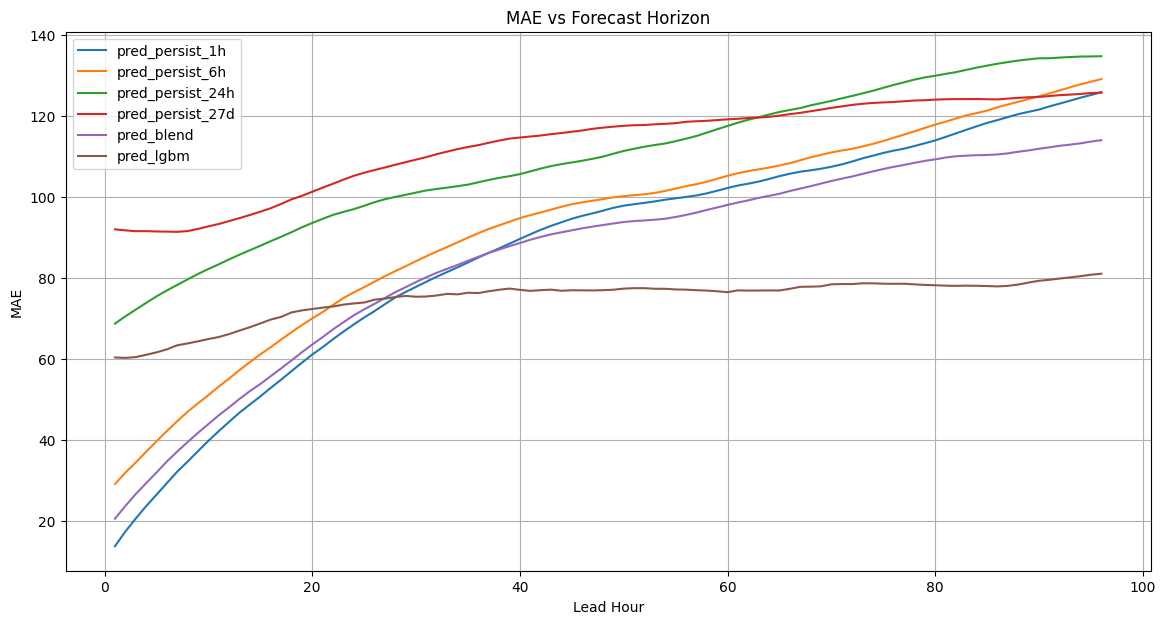

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=(14, 7))

for model in MODELS:

    g = metrics_by_lead[
        metrics_by_lead["model"] == model
    ]

    plt.plot(
        g["lead_hours"],
        g["mae"],
        label=model,
    )

plt.xlabel("Lead Hour")
plt.ylabel("MAE")
plt.title("MAE vs Forecast Horizon")

plt.grid(True)
plt.legend()

plt.show()

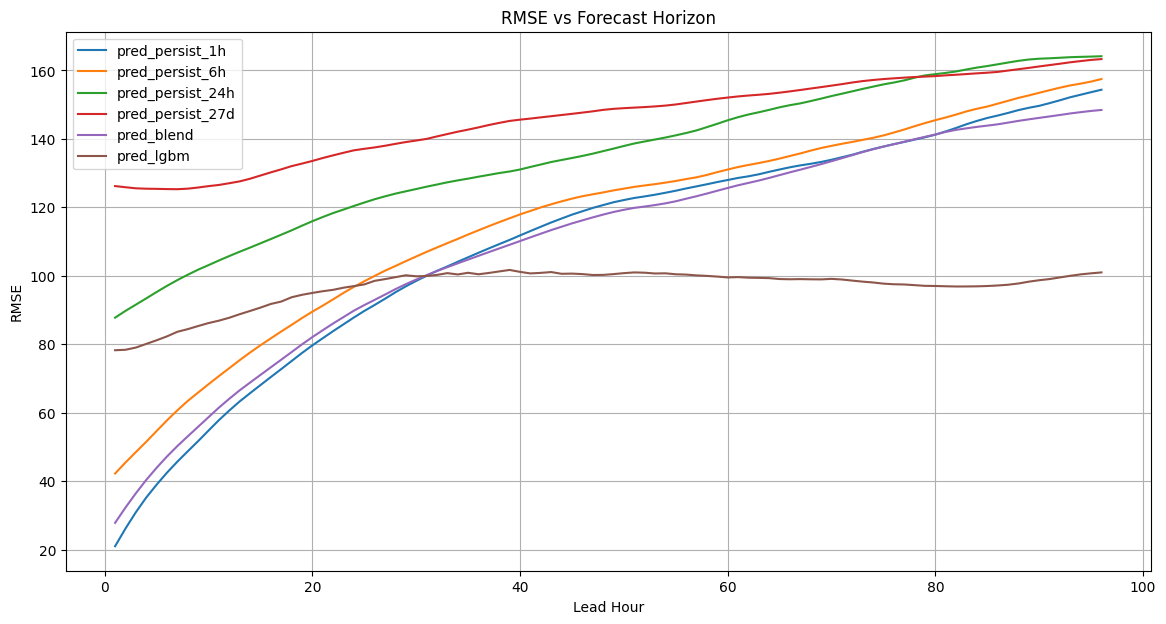

In [12]:
plt.figure(figsize=(14, 7))

for model in MODELS:

    g = metrics_by_lead[
        metrics_by_lead["model"] == model
    ]

    plt.plot(
        g["lead_hours"],
        g["rmse"],
        label=model,
    )

plt.xlabel("Lead Hour")
plt.ylabel("RMSE")
plt.title("RMSE vs Forecast Horizon")

plt.grid(True)
plt.legend()

plt.show()

In [13]:
def assign_bucket(lead_hours: int) -> str:

    if 1 <= lead_hours <= 24:
        return "short_1_24"

    if 25 <= lead_hours <= 48:
        return "medium_25_48"

    return "extended_49_96"

In [14]:
df = df.copy()
df["lead_bucket"] = df["lead_hours"].apply(assign_bucket)

train, valid = time_split(df, 0.8)

In [15]:
models = {}

for bucket in df["lead_bucket"].unique():

    train_bucket = train[
        train["lead_bucket"] == bucket
    ]

    model = train_lgbm(train_bucket)

    models[bucket] = model

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3149
[LightGBM] [Info] Number of data points in the train set: 140634, number of used features: 16
[LightGBM] [Info] Start training from score 423.298776
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3148
[LightGBM] [Info] Number of data points in the train set: 137248, number of used features: 16
[LightGBM] [Info] Start training from score 422.682028
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

In [16]:
valid["pred_persist_1h"] = valid["v_persist_1h"]
valid["pred_persist_6h"] = valid["v_persist_6h"]
valid["pred_persist_24h"] = valid["v_persist_24h"]
valid["pred_persist_27d"] = valid["v_persist_27d"]
valid["pred_blend"] = valid["baseline_blend"]

valid["pred_global_lgbm"] = lgbm_model.predict(valid[FEATURE_COLUMNS])

valid["pred_bucketed_lgbm"] = np.nan

for bucket, model in models.items():
    mask = valid["lead_bucket"] == bucket
    valid.loc[mask, "pred_bucketed_lgbm"] = model.predict(
        valid.loc[mask, FEATURE_COLUMNS]
    )

In [17]:
MODELS = [
    "pred_persist_1h",
    "pred_persist_6h",
    "pred_persist_24h",
    "pred_persist_27d",
    "pred_blend",
    "pred_global_lgbm",
    "pred_bucketed_lgbm",
]


rows = []

for lead_hour, g in valid.groupby("lead_hours"):
    y_true = g["target_v"].values

    for model_name in MODELS:
        y_pred = g[model_name].values

        rows.append({
            "lead_hours": lead_hour,
            "model": model_name,
            "mae": mean_absolute_error(y_true, y_pred),
            "rmse": root_mean_squared_error(y_true, y_pred),
            "bias": float(np.mean(y_pred - y_true)),
            "n": len(g),
        })


metrics_by_lead = pd.DataFrame(rows)
metrics_by_lead.head(7)

,lead_hours,model,mae,rmse,bias,n
0,1,pred_persist_1h,13.705298,20.974614,0.035099,1510
1,1,pred_persist_6h,29.065563,42.217734,0.458940,1510
2,1,pred_persist_24h,68.654305,87.755462,2.219868,1510
3,1,pred_persist_27d,91.939735,126.204336,-25.284106,1510
4,1,pred_blend,20.498041,27.809084,0.475725,1510
5,1,pred_global_lgbm,60.306697,78.241243,14.979075,1510
6,1,pred_bucketed_lgbm,28.432377,37.255845,-16.272687,1510


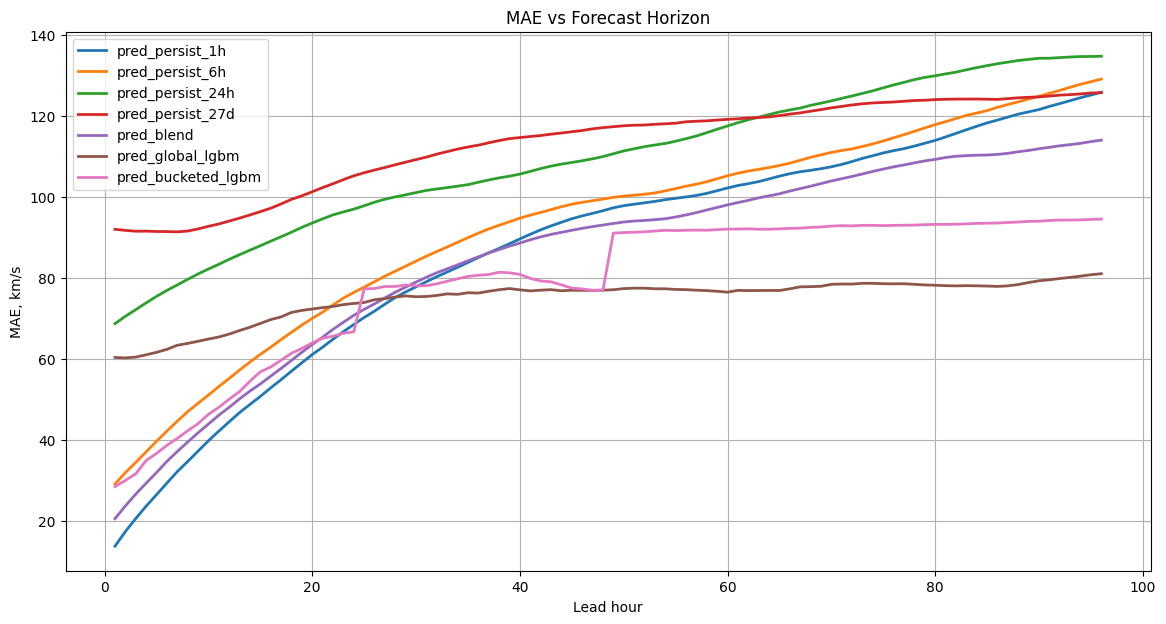

In [18]:
plt.figure(figsize=(14, 7))

for model_name in MODELS:
    g = metrics_by_lead[metrics_by_lead["model"] == model_name]

    plt.plot(
        g["lead_hours"],
        g["mae"],
        label=model_name,
        linewidth=2,
    )

plt.xlabel("Lead hour")
plt.ylabel("MAE, km/s")
plt.title("MAE vs Forecast Horizon")
plt.grid(True)
plt.legend()
plt.show()

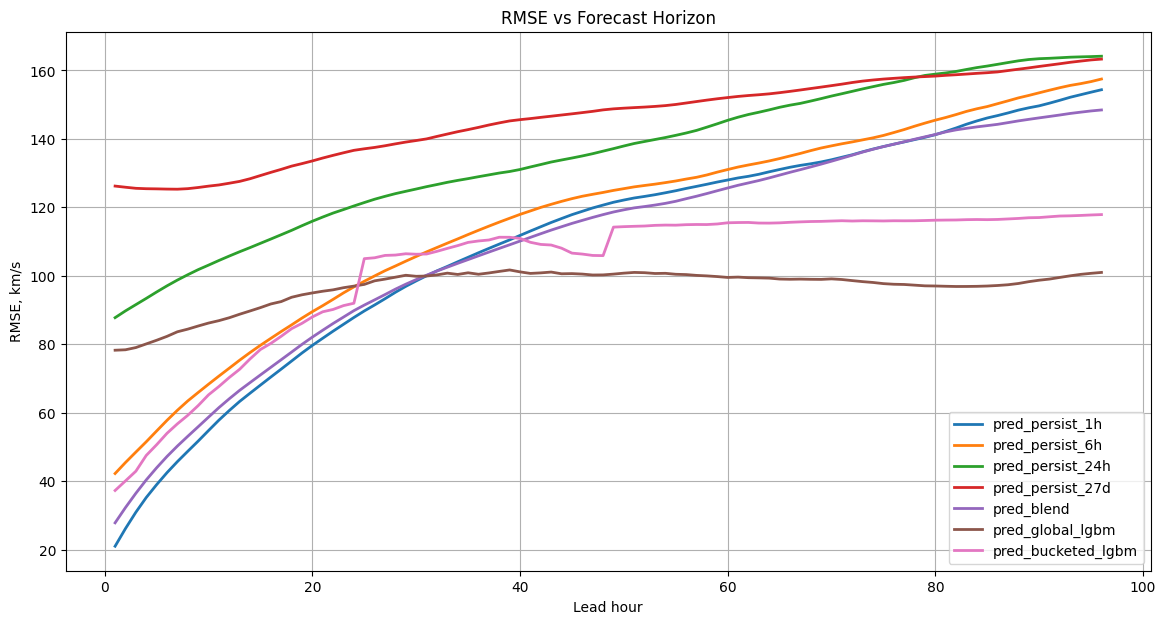

In [19]:
plt.figure(figsize=(14, 7))

for model_name in MODELS:
    g = metrics_by_lead[metrics_by_lead["model"] == model_name]

    plt.plot(
        g["lead_hours"],
        g["rmse"],
        label=model_name,
        linewidth=2,
    )

plt.xlabel("Lead hour")
plt.ylabel("RMSE, km/s")
plt.title("RMSE vs Forecast Horizon")
plt.grid(True)
plt.legend()
plt.show()

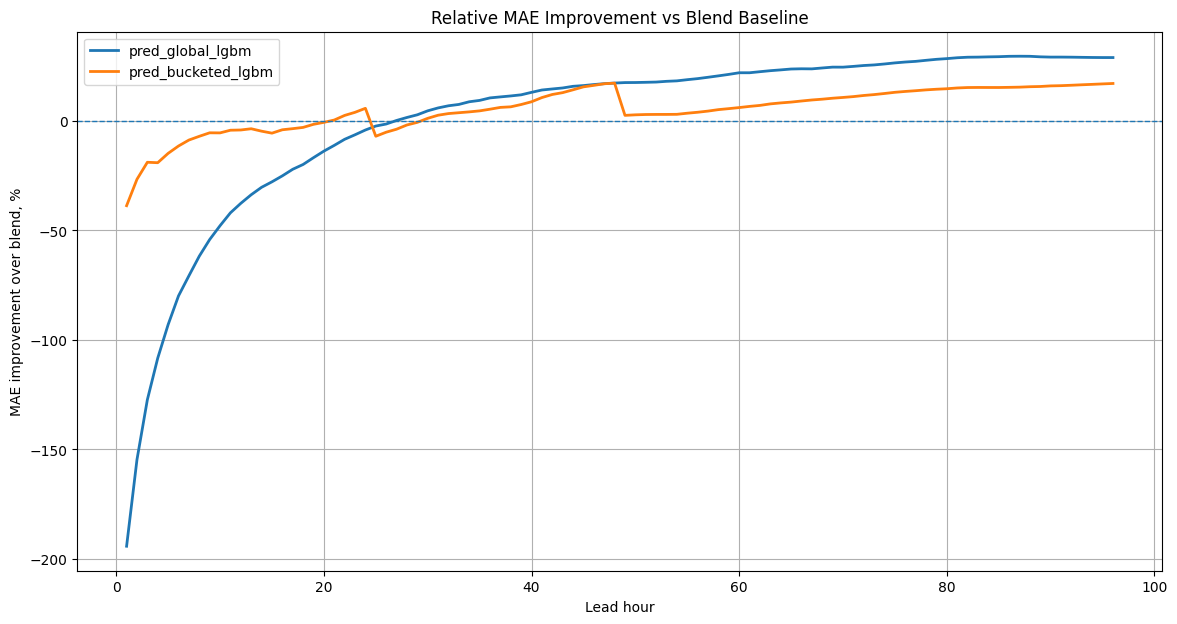

In [20]:
baseline_name = "pred_blend"

base = metrics_by_lead[
    metrics_by_lead["model"] == baseline_name
][["lead_hours", "mae"]].rename(columns={"mae": "baseline_mae"})

improvement = metrics_by_lead.merge(base, on="lead_hours")
improvement["mae_improvement_pct"] = (
    (improvement["baseline_mae"] - improvement["mae"])
    / improvement["baseline_mae"]
    * 100.0
)

plot_models = [
    "pred_global_lgbm",
    "pred_bucketed_lgbm",
]

plt.figure(figsize=(14, 7))

for model_name in plot_models:
    g = improvement[improvement["model"] == model_name]

    plt.plot(
        g["lead_hours"],
        g["mae_improvement_pct"],
        label=model_name,
        linewidth=2,
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Lead hour")
plt.ylabel("MAE improvement over blend, %")
plt.title("Relative MAE Improvement vs Blend Baseline")
plt.grid(True)
plt.legend()
plt.show()

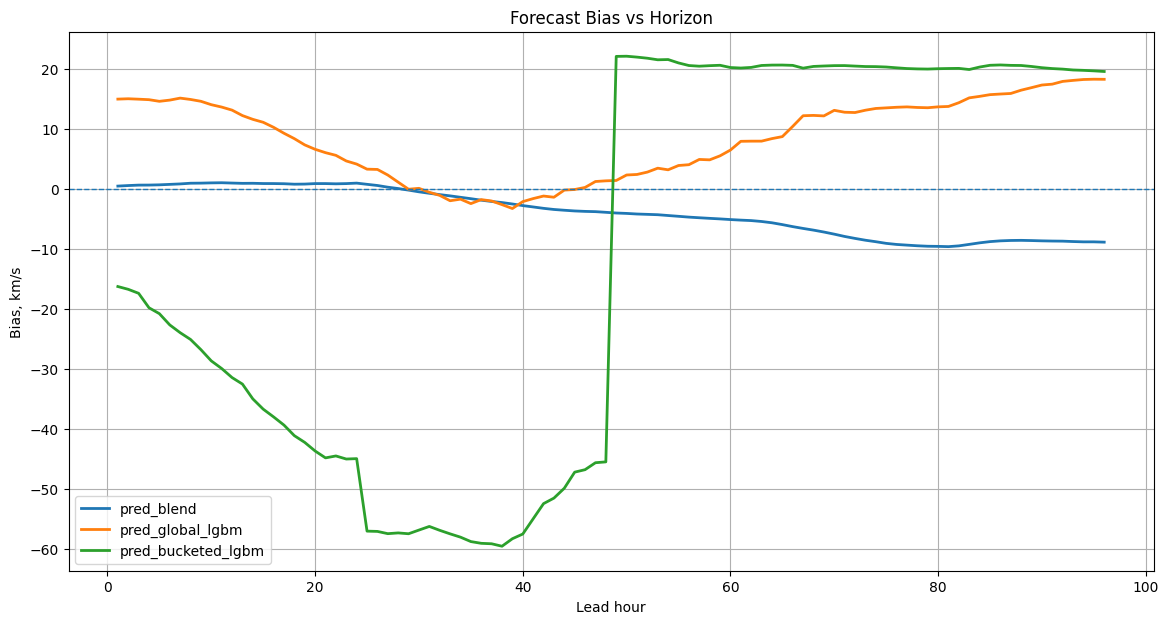

In [21]:
plt.figure(figsize=(14, 7))

for model_name in [
    "pred_blend",
    "pred_global_lgbm",
    "pred_bucketed_lgbm",
]:
    g = metrics_by_lead[metrics_by_lead["model"] == model_name]

    plt.plot(
        g["lead_hours"],
        g["bias"],
        label=model_name,
        linewidth=2,
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Lead hour")
plt.ylabel("Bias, km/s")
plt.title("Forecast Bias vs Horizon")
plt.grid(True)
plt.legend()
plt.show()

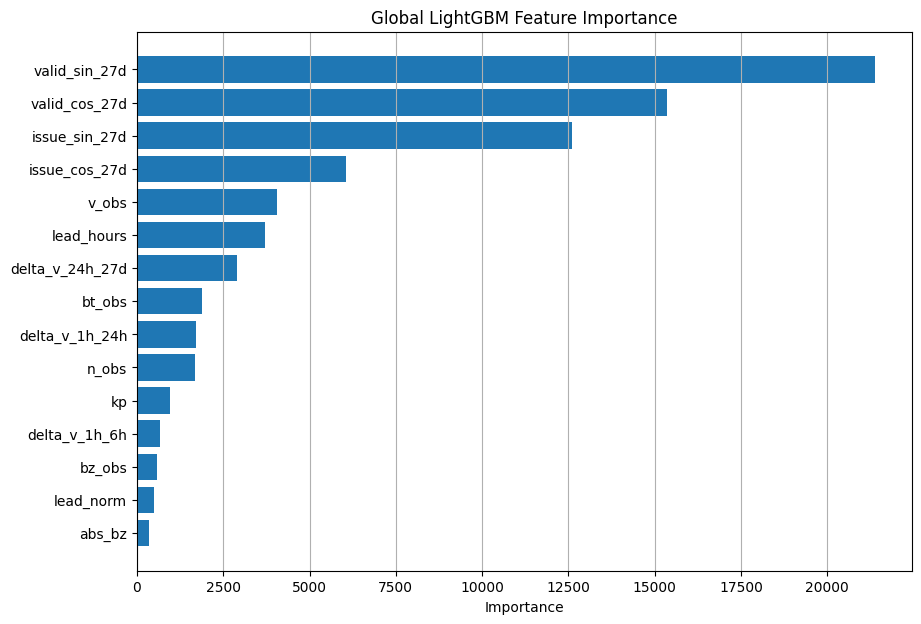

In [22]:
def plot_feature_importance(model, feature_columns, title, top_n=15):
    importance = pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 7))
    plt.barh(
        importance["feature"][::-1],
        importance["importance"][::-1],
    )
    plt.xlabel("Importance")
    plt.title(title)
    plt.grid(True, axis="x")
    plt.show()


plot_feature_importance(
    lgbm_model,
    FEATURE_COLUMNS,
    "Global LightGBM Feature Importance",
)

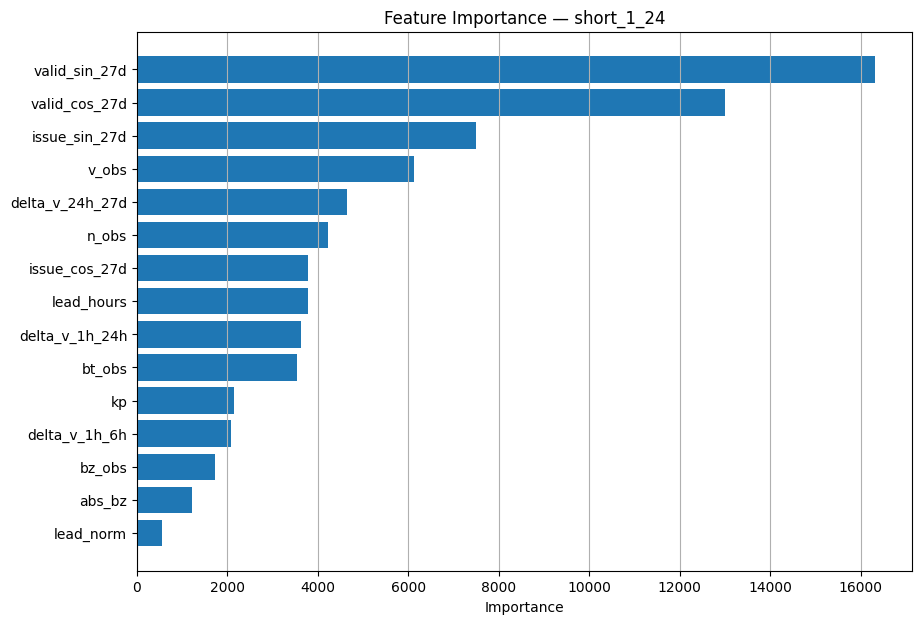

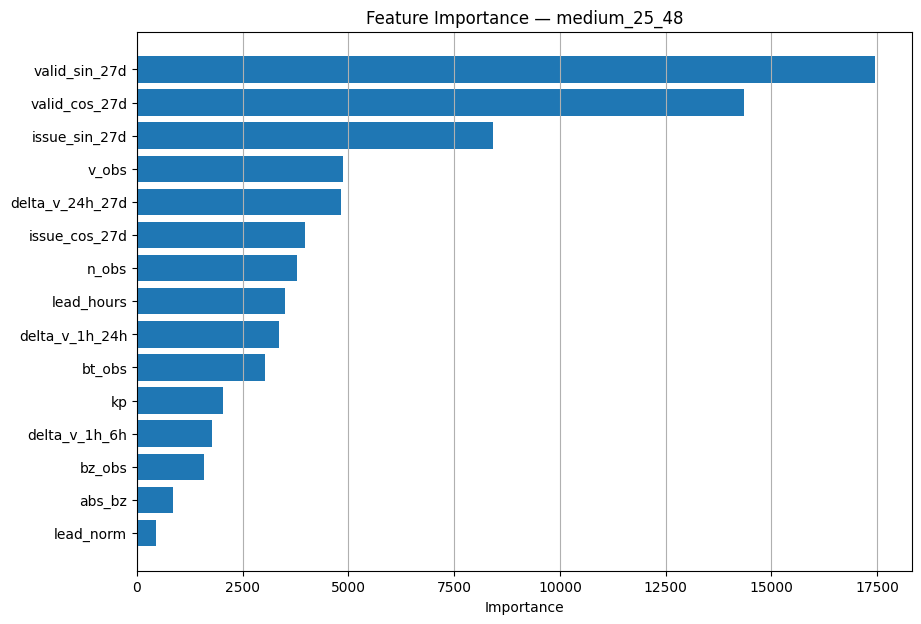

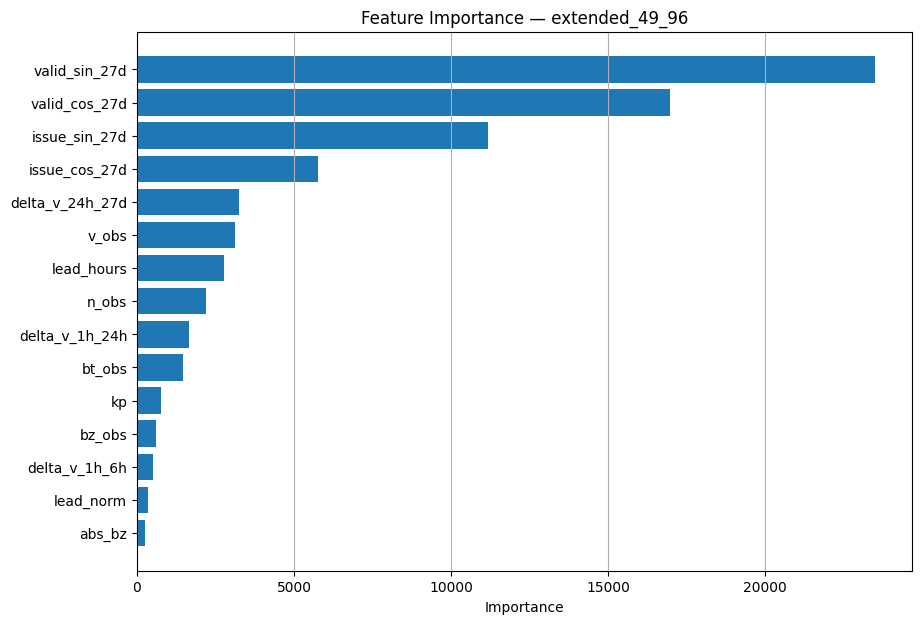

In [23]:
for bucket, model in models.items():
    plot_feature_importance(
        model,
        FEATURE_COLUMNS,
        f"Feature Importance — {bucket}",
    )

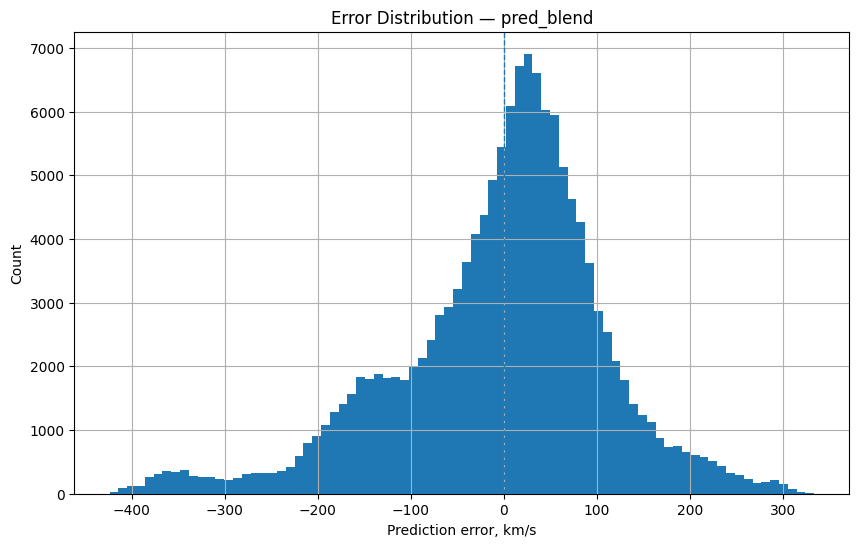

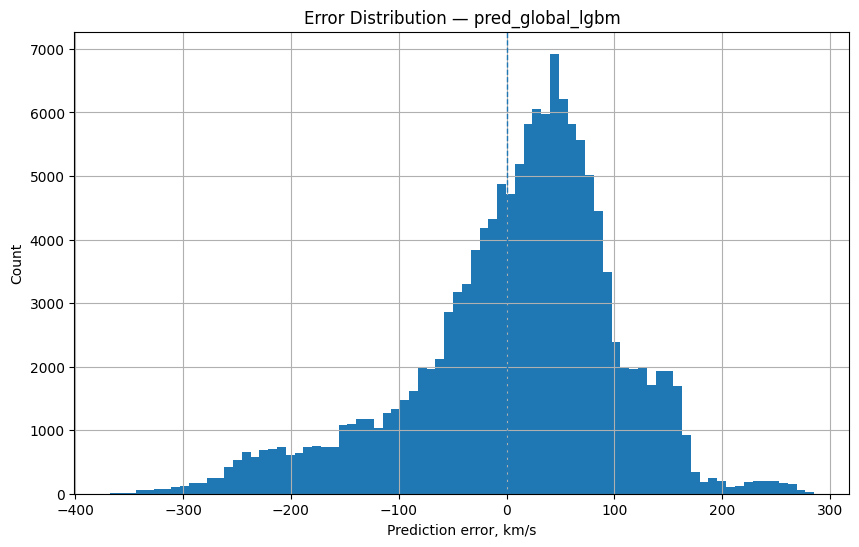

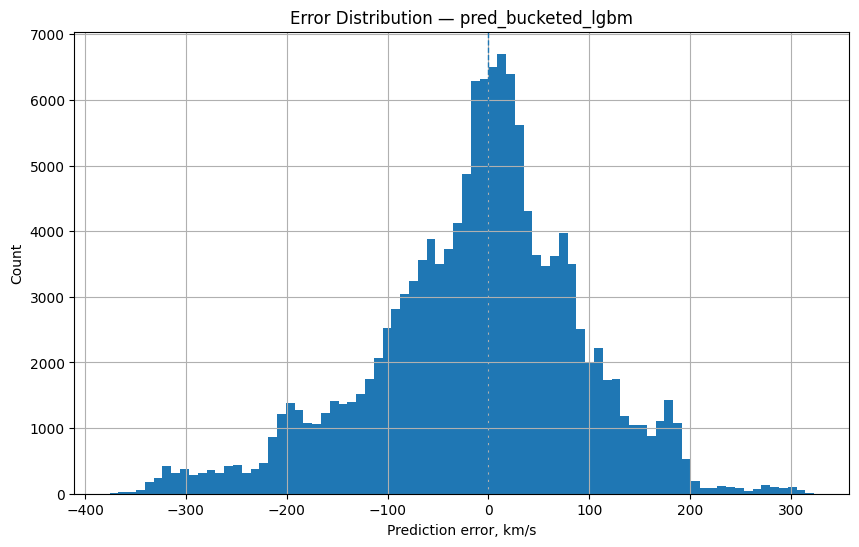

In [24]:
for model_name in [
    "pred_blend",
    "pred_global_lgbm",
    "pred_bucketed_lgbm",
]:
    err = valid[model_name] - valid["target_v"]

    plt.figure(figsize=(10, 6))
    plt.hist(err, bins=80)

    plt.axvline(0, linestyle="--", linewidth=1)

    plt.xlabel("Prediction error, km/s")
    plt.ylabel("Count")
    plt.title(f"Error Distribution — {model_name}")
    plt.grid(True)
    plt.show()

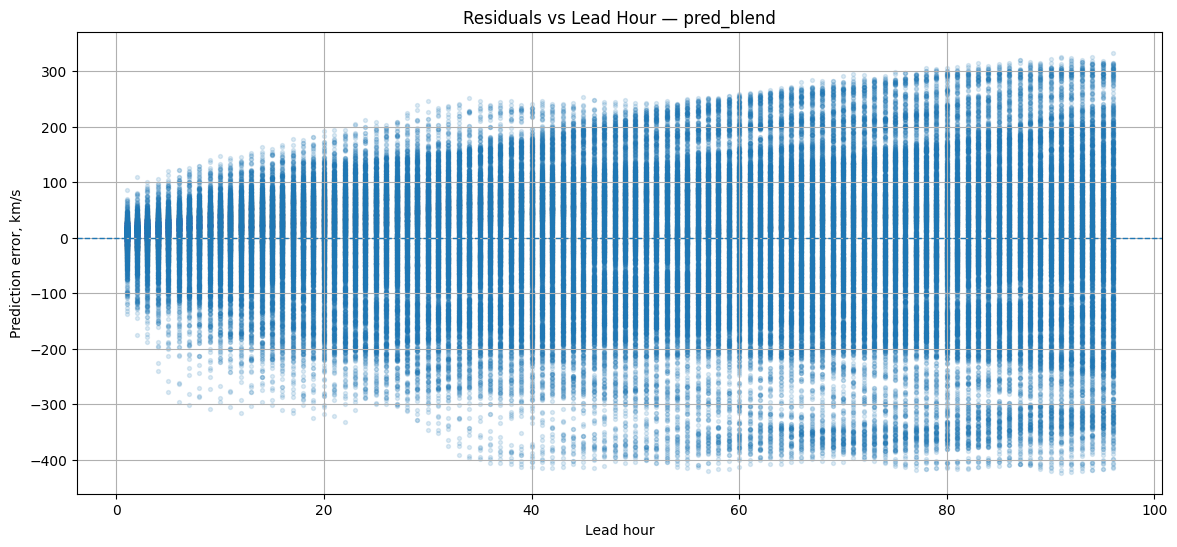

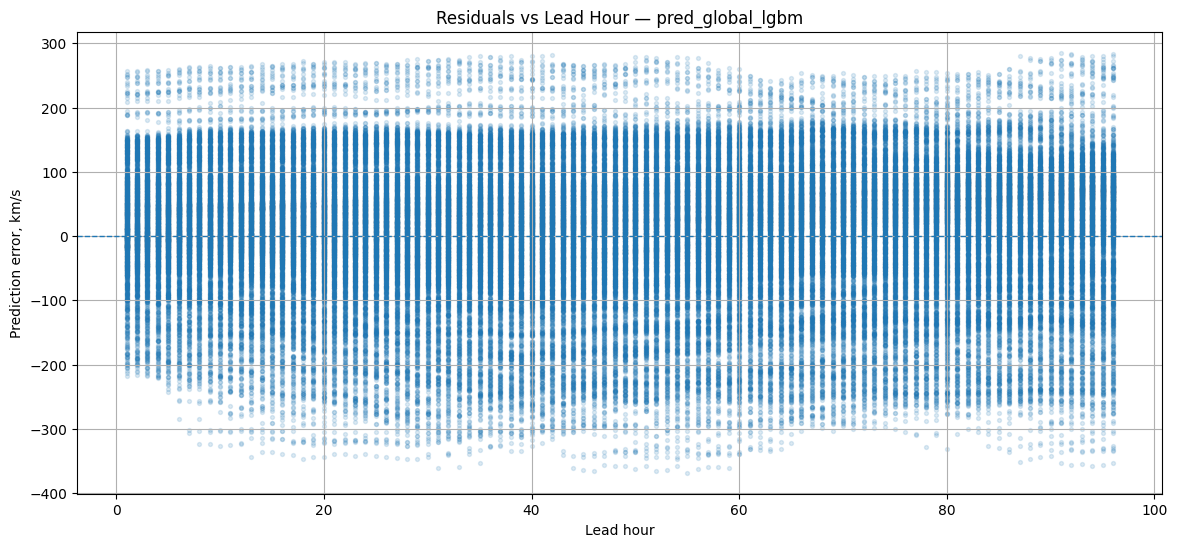

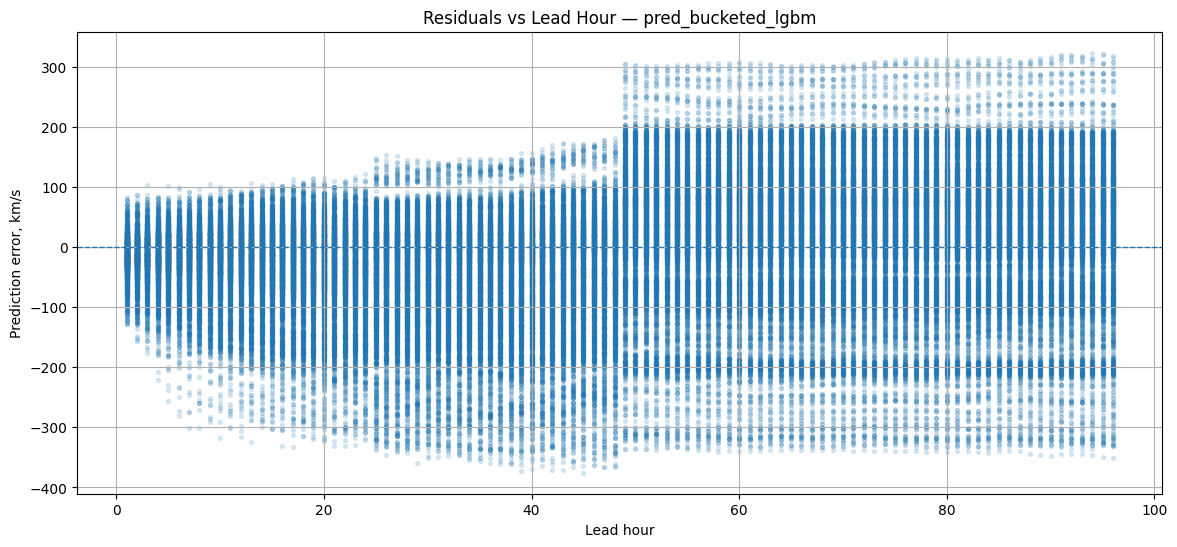

In [25]:
for model_name in [
    "pred_blend",
    "pred_global_lgbm",
    "pred_bucketed_lgbm",
]:
    err = valid[model_name] - valid["target_v"]

    plt.figure(figsize=(14, 6))
    plt.scatter(
        valid["lead_hours"],
        err,
        alpha=0.15,
        s=8,
    )

    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel("Lead hour")
    plt.ylabel("Prediction error, km/s")
    plt.title(f"Residuals vs Lead Hour — {model_name}")
    plt.grid(True)
    plt.show()

In [26]:
def plot_forecast_curve(issue_time):
    issue_time = pd.Timestamp(issue_time, tz="UTC")

    g = valid[valid["issue_time"] == issue_time].sort_values("lead_hours")

    if g.empty:
        print(f"No rows for issue_time={issue_time}")
        return

    plt.figure(figsize=(14, 7))

    plt.plot(
        g["valid_time"],
        g["target_v"],
        label="Observed target",
        linewidth=3,
    )

    for model_name in [
        "pred_blend",
        "pred_global_lgbm",
        "pred_bucketed_lgbm",
    ]:
        plt.plot(
            g["valid_time"],
            g[model_name],
            label=model_name,
            linewidth=2,
        )

    plt.xlabel("Valid time")
    plt.ylabel("Solar wind speed, km/s")
    plt.title(f"96h Forecast Curve from issue_time={issue_time}")
    plt.grid(True)
    plt.legend()
    plt.show()


In [27]:
event_issues = (
    valid
    .groupby("issue_time")["target_v"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

event_issues

issue_time
2023-11-07 18:00:00+00:00    735.0
2023-11-08 09:00:00+00:00    735.0
2023-11-07 02:00:00+00:00    735.0
2023-11-08 07:00:00+00:00    735.0
2023-11-08 03:00:00+00:00    735.0
2023-11-08 02:00:00+00:00    735.0
2023-11-08 04:00:00+00:00    735.0
2023-11-08 11:00:00+00:00    735.0
2023-11-08 08:00:00+00:00    735.0
2023-11-08 05:00:00+00:00    735.0
Name: target_v, dtype: float64

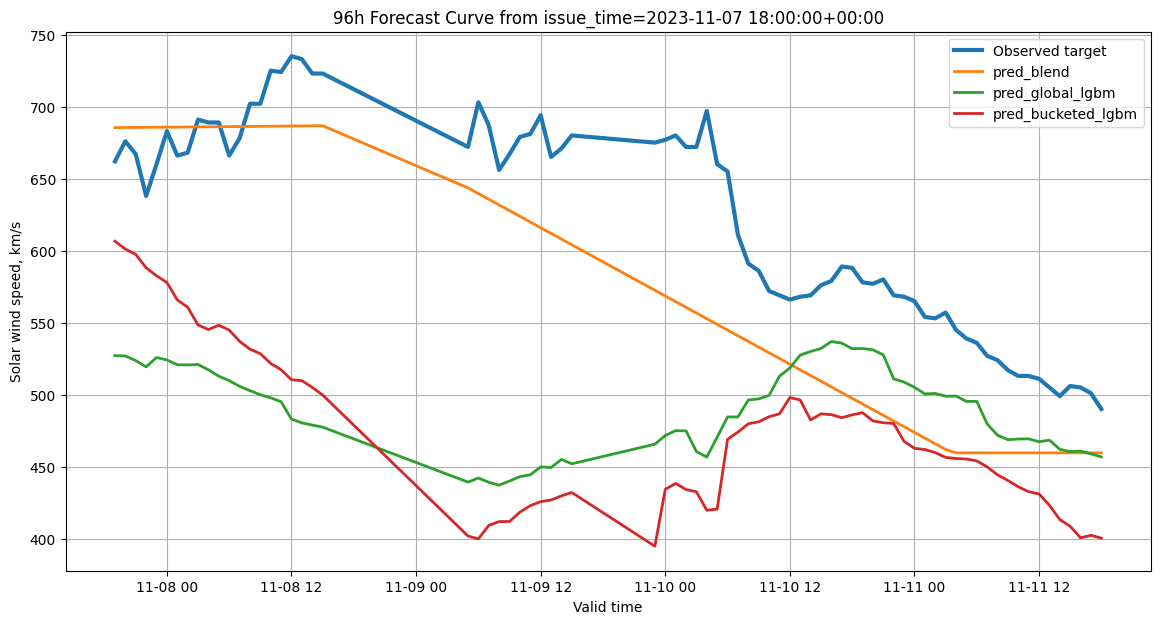

In [28]:
plot_forecast_curve("2023-11-07 18:00:00+00:00")

In [29]:
bucket_summary_rows = []

for bucket, g_bucket in valid.groupby("lead_bucket"):
    y_true = g_bucket["target_v"].values

    for model_name in MODELS:
        y_pred = g_bucket[model_name].values

        bucket_summary_rows.append({
            "bucket": bucket,
            "model": model_name,
            "mae": mean_absolute_error(y_true, y_pred),
            "rmse": root_mean_squared_error(y_true, y_pred),
            "bias": float(np.mean(y_pred - y_true)),
            "n": len(g_bucket),
        })


bucket_summary = pd.DataFrame(bucket_summary_rows)
bucket_summary.sort_values(["bucket", "mae"])

,bucket,model,mae,rmse,bias,n
5,extended_49_96,pred_global_lgbm,78.029540,98.943925,11.314767,67704
6,extended_49_96,pred_bucketed_lgbm,92.724668,115.943191,20.508071,67704
4,extended_49_96,pred_blend,104.269921,134.964946,-7.232375,67704
0,extended_49_96,pred_persist_1h,109.998789,137.041905,5.675292,67704
1,extended_49_96,pred_persist_6h,113.047146,140.484134,5.945350,67704
3,extended_49_96,pred_persist_27d,121.814103,155.966783,-22.129948,67704
2,extended_49_96,pred_persist_24h,124.477919,153.194876,7.892458,67704
12,medium_25_48,pred_global_lgbm,76.150111,100.287100,-0.457822,34738
13,medium_25_48,pred_bucketed_lgbm,78.815405,107.920596,-54.967200,34738
11,medium_25_48,pred_blend,84.549291,106.133965,-1.851764,34738
